# Notebook 09 - Story Generation

VisionNarrator | Stage 9

---

## 1. Objective

Turn the structured scene representations of Notebook 08 into text at three levels of freedom, and keep every level anchored to what the image actually shows.

Structured record (entities · actions · attributes · scene · relations · caption)
      ↓
Short description → one grounded sentence
Detailed explanation → one factual paragraph
Story → 4–6 sentence narrative with a beginning, middle and end
      ↓
Grounding / hallucination check → repair pass
      ↓
Evaluation, comparison with the caption, visualization, saved outputs
      ↓
End-to-end demonstration: image → caption → semantics → story

Generation uses a local instruction-tuned language model (Qwen2.5-1.5B-Instruct through `transformers`, ~3 GB in fp16); the semantic functions of Notebook 08 are imported from src/semantics.py.

Setup: imports, configuration, device, paths.

STORY_MODEL_NAME = Qwen/Qwen2.5-1.5B-Instruct
NUM_RECORDS = None (all records from Notebook 08)
TEMPERATURE = 0.6 / TOP_P = 0.9 (story only; description and explanation decode greedily)
MAX_NEW_TOKENS = 40 / 130 / 220
MAX_REPAIRS = 1 (regenerate once when the check fails)
MIN_ENTITY_COVERAGE = 0.5 (a text that mentions fewer than half of the record's entities also triggers a repair)
VIS_NUM_IMAGES = 4
DEMO_NUM_IMAGES = 2

Memory: the story model needs ~3.1 GB of GPU memory and the captioner in section 14 another ~1.5 GB. Close other notebook kernels first.


In [1]:
import json
import math
import random
import subprocess
import sys
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms as T
from transformers import AutoTokenizer, AutoModelForCausalLM

STORY_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
NUM_RECORDS = None
SEED = 42
TEMPERATURE = 0.6
TOP_P = 0.9
MAX_NEW_TOKENS = {"short_description": 40, "detailed_explanation": 130, "story": 220}
MAX_REPAIRS = 1
MIN_ENTITY_COVERAGE = 0.5
VIS_NUM_IMAGES = 4
DEMO_NUM_IMAGES = 2

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 80)

def resolve_base_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "data").exists():
        return cwd
    if (cwd.parent / "src" / "data").exists():
        return cwd.parent
    return cwd

BASE_DIR = resolve_base_dir()
DATA_DIR = BASE_DIR / "src" / "data"
DEMO_DIR = DATA_DIR / "demo"
MODEL_DIR = BASE_DIR / "src" / "models"
RESULTS_DIR = BASE_DIR / "results"
DOCS_DIR = BASE_DIR / "docs"

sys.path.insert(0, str(BASE_DIR))
from src import semantics as sem

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)} | {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    try:
        query = subprocess.run(["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,noheader,nounits"], capture_output=True, text=True, check=True)
        used_mib, total_mib = (int(v) for v in query.stdout.strip().split(","))
        print(f"GPU memory in use before this notebook: {used_mib:,} / {total_mib:,} MiB")
        if used_mib > 2048:
            print("WARNING: more than 2 GB already in use - close other notebook kernels before loading the story model")
    except Exception as error:
        print(f"nvidia-smi not available: {error}")
print(f"STORY_MODEL_NAME={STORY_MODEL_NAME}")
print(f"MAX_NEW_TOKENS={MAX_NEW_TOKENS} | TEMPERATURE={TEMPERATURE} | TOP_P={TOP_P} | MAX_REPAIRS={MAX_REPAIRS} | MIN_ENTITY_COVERAGE={MIN_ENTITY_COVERAGE}")
print(f"RESULTS_DIR: {RESULTS_DIR}")


c:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU | 8.6 GB
GPU memory in use before this notebook: 2,609 / 8,188 MiB
STORY_MODEL_NAME=Qwen/Qwen2.5-1.5B-Instruct
MAX_NEW_TOKENS={'short_description': 40, 'detailed_explanation': 130, 'story': 220} | TEMPERATURE=0.6 | TOP_P=0.9 | MAX_REPAIRS=1 | MIN_ENTITY_COVERAGE=0.5
RESULTS_DIR: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\results


## 2. Load Semantic Representations

results/story_inputs.jsonl → one record per image: caption, compact semantics, flags, prompt block
results/semantic_representations.json → full records (confidences, attention focus, reference overlap)

Image paths are re-attached (test images from test.csv, demo images from src/data/demo) for the visualizations.


In [2]:
story_inputs_path = RESULTS_DIR / "story_inputs.jsonl"
representations_path = RESULTS_DIR / "semantic_representations.json"

with open(story_inputs_path, encoding="utf-8") as f:
    records = [json.loads(line) for line in f if line.strip()]
with open(representations_path, encoding="utf-8") as f:
    representations = {rep["image"]: rep for rep in json.load(f)}

if NUM_RECORDS is not None:
    records = records[:NUM_RECORDS]

test_paths = pd.read_csv(DATA_DIR / "test.csv").drop_duplicates(subset="image").set_index("image")["image_path"]
for record in records:
    record["image_path"] = str(test_paths[record["image"]]) if record["source"] == "test" else str(DEMO_DIR / record["image"])
    record["representation"] = representations.get(record["image"], {})

flag_counts = Counter(flag.split(":")[0].split(" (")[0] for record in records for flag in record["flags"])

print(f"Records: {len(records)} | test {sum(r['source'] == 'test' for r in records)} | demo {sum(r['source'] == 'demo' for r in records)}")
print(f"Records with flags: {sum(1 for r in records if r['flags'])}")
print(f"Flag types: {dict(flag_counts)}")
print()
print(f"[0] {records[0]['image']}")
print(records[0]["prompt"])

records_df = pd.DataFrame(
    {
        "image": [r["image"] for r in records],
        "caption": [r["caption"] for r in records],
        "entities": [len(r["semantics"]["entities"]) for r in records],
        "actions": [len(r["semantics"]["actions"]) for r in records],
        "setting": [r["semantics"]["scene"]["setting"] for r in records],
        "flags": [len(r["flags"]) for r in records],
    }
)
display(records_df.head(10))


Records: 24 | test 24 | demo 0
Records with flags: 14
Flag types: {'greedy/beam disagreement': 11, 'repeated entity': 1, 'repeated bigram': 3, 'no action': 1}

[0] 10010052.jpg
Setting: unspecified
Characters: a woman wearing blue shirt, blue jeans
Objects: a skateboard
Actions: woman stand on skateboard (uncertain)
Relations: woman stand on skateboard
Caption: A woman in a blue shirt and blue jeans is standing on a skateboard .


,image,caption,entities,actions,setting,flags
0,10010052.jpg,A woman in a blue shirt and blue jeans is standing on a skateboard .,2,1,unknown,0
1,1001465944.jpg,A group of people walking down a street .,2,1,outdoor,0
2,1003163366.jpg,A man and a dog are sleeping on a bench .,3,1,unknown,0
3,100759042.jpg,A man in a gray hooded sweatshirt is looking at his cellphone .,2,1,unknown,1
4,10082347.jpg,A man in a yellow shirt is holding onto a pole .,2,1,unknown,1
5,1009434119.jpg,The black and white dog is running on the grass .,2,1,outdoor,1
6,1009692167.jpg,A man in a green vest is walking his dog on the street .,3,1,outdoor,0
7,1010470346.jpg,Two men are standing in front of a building with a white building in the bac...,5,1,outdoor,1
8,101093029.jpg,A man and a woman are walking in front of a building .,4,1,outdoor,1
9,1012150929.jpg,A young boy in a red shirt is playing an arcade game .,2,1,unknown,0


## 3. Define Story Structure

Three outputs per image, increasing in freedom, all bound to the same record:

| Output | Form | Freedom | Decoding |
|---|---|---|---|
| Short description | 1 sentence, ≤ 25 words | none — restate the record | greedy |
| Detailed explanation | 3–5 sentences, factual | low — what, who, where, doing; hedge uncertain items | greedy |
| Story | 4–6 sentences, beginning → middle → end | moderate — feelings, motives, small actions; no new people, animals, objects, places, names | sampled |

Story beats (folded generically into the story instruction in section 5; `story_beats` renders them per record for inspection):

opening → setting + characters as they are
development → the actions and relations, in order
closing → what the characters do next, without leaving the scene


In [3]:
STORY_STRUCTURE = {
    "short_description": {"sentences": (1, 1), "max_words": 25, "max_new_tokens": MAX_NEW_TOKENS["short_description"], "sample": False},
    "detailed_explanation": {"sentences": (3, 5), "max_words": 120, "max_new_tokens": MAX_NEW_TOKENS["detailed_explanation"], "sample": False},
    "story": {"sentences": (4, 6), "max_words": 160, "max_new_tokens": MAX_NEW_TOKENS["story"], "sample": True},
}

def prompt_fields(record):
    fields = {}
    for line in record["prompt"].splitlines():
        if ":" in line:
            key, value = line.split(":", 1)
            fields[key.strip()] = value.strip()
    return fields

def story_beats(record):
    fields = prompt_fields(record)
    return {
        "opening": f"Introduce the setting ({fields.get('Setting', 'unspecified')}) and the characters ({fields.get('Characters', 'none identified')}) exactly as listed.",
        "development": f"Show what happens: {fields.get('Actions', 'none identified')}. Relations to keep: {fields.get('Relations', 'none')}.",
        "closing": "End with what the characters do next while staying in the same place; do not add anyone or anything new.",
    }

for mode, spec in STORY_STRUCTURE.items():
    print(f"{mode:<21} sentences {spec['sentences']} | max words {spec['max_words']} | max_new_tokens {spec['max_new_tokens']} | sampled {spec['sample']}")
print()
for beat, text in story_beats(records[0]).items():
    print(f"{beat}: {text}")


short_description     sentences (1, 1) | max words 25 | max_new_tokens 40 | sampled False
detailed_explanation  sentences (3, 5) | max words 120 | max_new_tokens 130 | sampled False
story                 sentences (4, 6) | max words 160 | max_new_tokens 220 | sampled True

opening: Introduce the setting (unspecified) and the characters (a woman wearing blue shirt, blue jeans) exactly as listed.
development: Show what happens: woman stand on skateboard (uncertain). Relations to keep: woman stand on skateboard.
closing: End with what the characters do next while staying in the same place; do not add anyone or anything new.


## 4. Story Generation Strategy

Local instruction-tuned LLM (Qwen2.5-1.5B-Instruct)
      ↓
chat template: system prompt with grounding rules + one worked example (user / assistant turn) + the record
      ↓
greedy decoding for factual outputs, nucleus sampling (T = 0.7, p = 0.9, fixed seed per record) for the story
      ↓
grounding check → one repair pass with explicit feedback (section 9)

Why not the captioning GPT-2: it is a plain language model without instruction tuning, so it cannot follow "use only these elements". A 1.5B instruct model follows the format but still embellishes, which is exactly what the grounding check measures and repairs.

If the model cannot be loaded (no GPU, no download), `llm_available` is False and deterministic fallbacks keep the notebook runnable: the caption stands in for the short description and the rendered prompt for the explanation and story.


In [4]:
llm_available = False
try:
    story_tokenizer = AutoTokenizer.from_pretrained(STORY_MODEL_NAME)
    story_model = AutoModelForCausalLM.from_pretrained(STORY_MODEL_NAME, dtype=torch.float16 if device.type == "cuda" else torch.float32).to(device).eval()
    llm_available = True
    print(f"Loaded {STORY_MODEL_NAME} | {sum(p.numel() for p in story_model.parameters()) / 1e9:.2f}B parameters | dtype {next(story_model.parameters()).dtype}")
    if device.type == "cuda":
        print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
except Exception as error:
    print(f"Story model unavailable ({type(error).__name__}: {str(error)[:120]}) - using deterministic fallbacks")

@torch.no_grad()
def generate_text(messages, max_new_tokens, sample=False, seed=SEED):
    inputs = story_tokenizer.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt", return_dict=True).to(device)
    n_prompt = inputs["input_ids"].shape[-1]
    torch.manual_seed(seed)
    generate_kwargs = dict(max_new_tokens=max_new_tokens, pad_token_id=story_tokenizer.eos_token_id)
    if sample:
        generate_kwargs.update(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P)
    else:
        generate_kwargs.update(do_sample=False)
    output = story_model.generate(**inputs, **generate_kwargs)
    return story_tokenizer.decode(output[0, n_prompt:], skip_special_tokens=True).strip()

if llm_available:
    start = time.time()
    demo = generate_text([{"role": "user", "content": "Reply with one short sentence: what does an image captioning model do?"}], max_new_tokens=40)
    print(f"Test generation ({time.time() - start:.1f}s): {demo}")


Loading weights: 100%|██████████| 338/338 [00:02<00:00, 145.22it/s]


Loaded Qwen/Qwen2.5-1.5B-Instruct | 1.54B parameters | dtype torch.float16
GPU memory allocated: 3.09 GB
Test generation (1.2s): An image captioning model generates text descriptions for images.


## 5. Prompt / Generation Template

system → grounding rules shared by all three outputs
example → one worked record and its ideal answer for the requested mode (a single demonstration keeps a 1.5B model on format)
user → the record's prompt block (lines whose value is unspecified / none identified are dropped, so nothing empty can be echoed) + the mode instruction (+ feedback for a repair)

The story instruction carries the beats of section 3 in generic form (setting and characters → actions → what they do next); record-specific text is never appended after the instruction, because a small model tends to copy such trailing lines into its answer. Rules in the system prompt: only listed characters, objects, actions and setting; no names; nothing marked uncertain is stated as fact; the marker words never appear in the text; plain English; return only the requested text.


In [5]:
SYSTEM_PROMPT = (
    "You write about a single photograph using only a structured description of it. "
    "Rules: mention only the characters, objects, actions and setting that are listed; never give anyone a name; "
    "do not add people, animals, objects, places, weather, time of day or events that are not listed; "
    "treat anything marked (uncertain) as unsure and describe it vaguely or leave it out; "
    "never write the words uncertain, unspecified, unknown, unclear or none identified - if no setting is given, simply do not describe the place at all; "
    "write plain, concrete English; return only the requested text with no title, list or explanation."
)

EXAMPLE_PROMPT = (
    "Setting: outdoor, on the grass\n"
    "Characters: two children; a dog (uncertain)\n"
    "Objects: a red ball\n"
    "Actions: children play with ball; children run\n"
    "Relations: children play with ball; children on grass\n"
    "Caption: Two children are playing with a red ball on the grass ."
)
EXAMPLE_ANSWERS = {
    "short_description": "Two children play with a red ball on the grass.",
    "detailed_explanation": "Two children are on a patch of grass outdoors. They are playing with a red ball and running as they play. There may also be a dog nearby, though that is hard to tell. Nothing else about the place is known.",
    "story": "Two children raced across the grass with a red ball bouncing between them. The taller one kicked it hard, and the other sprinted after it, laughing. Something small moved at the edge of the grass, perhaps a dog, but the children were too busy to notice. When the ball finally rolled to a stop, they flopped down side by side to catch their breath. Then one of them stood, picked up the ball, and the game began again.",
}

MODE_INSTRUCTIONS = {
    "short_description": "Write ONE sentence of at most 25 words that describes the photograph using the listed elements.",
    "detailed_explanation": "Write one factual paragraph of 3 to 5 sentences explaining what the photograph shows: who or what is present, what they look like, what they are doing and where. Do not tell a story and do not speculate beyond the list.",
    "story": "Write a short story of 4 to 6 sentences about this photograph: begin with the setting and the listed characters as they are, then show the listed actions happening, then end with what the characters do next without leaving the scene. You may add feelings, motives and small movements of the listed characters, but no new characters, animals, objects, places or names.",
}

EMPTY_VALUES = {"unspecified", "none identified", "none", "unknown"}

def prompt_block(record):
    lines = []
    for line in record["prompt"].splitlines():
        key, _, value = line.partition(":")
        if value.strip().lower() in EMPTY_VALUES:
            continue
        lines.append(line)
    return "\n".join(lines)

def build_messages(record, mode, feedback=None):
    example_user = f"Photograph description:\n{EXAMPLE_PROMPT}\n\n{MODE_INSTRUCTIONS[mode]}"
    user = f"Photograph description:\n{prompt_block(record)}\n\n{MODE_INSTRUCTIONS[mode]}"
    if feedback:
        user += f"\n\nYour previous attempt broke the rules: {feedback} Rewrite the whole text and follow the rules strictly."
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": example_user},
        {"role": "assistant", "content": EXAMPLE_ANSWERS[mode]},
        {"role": "user", "content": user},
    ]

print("=== system ===")
print(SYSTEM_PROMPT)
print()
print("=== example (story) ===")
print(EXAMPLE_PROMPT)
print("->", EXAMPLE_ANSWERS["story"])
print()
print("=== user (story) ===")
print(build_messages(records[0], "story")[-1]["content"])


=== system ===
You write about a single photograph using only a structured description of it. Rules: mention only the characters, objects, actions and setting that are listed; never give anyone a name; do not add people, animals, objects, places, weather, time of day or events that are not listed; treat anything marked (uncertain) as unsure and describe it vaguely or leave it out; never write the words uncertain, unspecified, unknown, unclear or none identified - if no setting is given, simply do not describe the place at all; write plain, concrete English; return only the requested text with no title, list or explanation.

=== example (story) ===
Setting: outdoor, on the grass
Characters: two children; a dog (uncertain)
Objects: a red ball
Actions: children play with ball; children run
Relations: children play with ball; children on grass
Caption: Two children are playing with a red ball on the grass .
-> Two children raced across the grass with a red ball bouncing between them. The t

## 6. Generate Short Description

record → one grounded sentence (greedy decoding)

The caption itself is the baseline: it is the captioner's own one-sentence description, so the LLM sentence should say the same things in different words, not more.


In [6]:
def generate_for(record, mode, seed=SEED, feedback=None):
    if not llm_available:
        return record["caption"] if mode == "short_description" else record["prompt"].replace("\n", " ")
    spec = STORY_STRUCTURE[mode]
    return generate_text(build_messages(record, mode, feedback), spec["max_new_tokens"], sample=spec["sample"], seed=seed)

start = time.time()
for record in records:
    record["short_description"] = generate_for(record, "short_description")
print(f"Short descriptions: {len(records)} in {time.time() - start:.0f}s")

display(pd.DataFrame({"caption": [r["caption"] for r in records], "short_description": [r["short_description"] for r in records]}).head(8))


Short descriptions: 24 in 11s


,caption,short_description
0,A woman in a blue shirt and blue jeans is standing on a skateboard .,A woman stands on a skateboard in a blue shirt and blue jeans.
1,A group of people walking down a street .,A group of people walks down a street.
2,A man and a dog are sleeping on a bench .,A man sleeps on a bench while a dog rests nearby.
3,A man in a gray hooded sweatshirt is looking at his cellphone .,A man in a gray hoodie looks at his cellphone.
4,A man in a yellow shirt is holding onto a pole .,A man in a yellow shirt holds onto a pole.
5,The black and white dog is running on the grass .,A black and white dog runs on the grass.
6,A man in a green vest is walking his dog on the street .,A man in a green vest walks his dog on the street.
7,Two men are standing in front of a building with a white building in the bac...,Two men stand in front of a white building with another building in the back...


## 7. Generate Detailed Explanation

record → 3–5 factual sentences (greedy decoding)

Who / what · appearance · action · place. Uncertain items are hedged, nothing outside the record is asserted.


In [7]:
start = time.time()
for record in records:
    record["detailed_explanation"] = generate_for(record, "detailed_explanation")
print(f"Detailed explanations: {len(records)} in {time.time() - start:.0f}s")

for record in records[:2]:
    print(f"{record['image']} | {record['caption']}")
    print(f"   {record['detailed_explanation']}")
    print()


Detailed explanations: 24 in 30s
10010052.jpg | A woman in a blue shirt and blue jeans is standing on a skateboard .
   A woman in a blue shirt and blue jeans stands on a skateboard.

1001465944.jpg | A group of people walking down a street .
   A group of people can be seen walking down a street. The exact number of people is uncertain, but there appears to be several individuals in the scene. Each person seems to be engaged in the act of walking along the street, moving their bodies forward while maintaining balance and pace. The specific details of each individual's appearance or attire are not provided, making them indistinguishable from one another. The location is clearly set outside, likely in an urban area, as indicated by the presence of a street.



## 8. Generate Story

record + beats → 4–6 sentence story (nucleus sampling, seed = SEED + record index, so every story is reproducible)

This is the initial story; section 9 checks it and may regenerate it once.


In [8]:
start = time.time()
for idx, record in enumerate(records):
    record["story_initial"] = generate_for(record, "story", seed=SEED + idx)
print(f"Stories: {len(records)} in {time.time() - start:.0f}s")

for record in records[:2]:
    print(f"{record['image']} | {record['caption']}")
    print(f"   {record['story_initial']}")
    print()


Stories: 24 in 93s
10010052.jpg | A woman in a blue shirt and blue jeans is standing on a skateboard .
   The woman in the blue shirt and blue jeans stood on her skateboard, balancing precariously on the metal frame. Her eyes scanned the horizon for any sign of danger or interest from passersby. She felt an intense mix of excitement and apprehension, knowing she was venturing into uncharted territory. With a deep breath, she pushed off from the ground, feeling the rush of wind against her skin as she soared above the pavement. Her heart pounded in her chest, yet she couldn't help but smile, eager to see where her adventure would take her.

1001465944.jpg | A group of people walking down a street .
   The sun was just beginning to rise over the city, casting long shadows across the cobblestone streets below. A group of people strolled leisurely along the bustling avenue, chatting animatedly under the warm morning light. Some wore casual outfits, while others sported smart suits for work

## 9. Grounding / Hallucination Check

allowed vocabulary = record entities (+ common synonyms) + attributes + clothing + scene locations + cues + action verbs + caption lemmas + neutral narrative words

For every generated text (spaCy lemmas):

- capitalized proper nouns / named entities → invented names or places
- unlisted person or animal nouns → new characters
- unlisted location nouns → new places
- other unlisted concrete nouns → new details (sun, mountains, sidewalk, ...); abstract nouns (-ness, -tion, -ment, feelings, body parts, time words) are neutral
- grounded ratio = supported content nouns / all content nouns
- entity coverage = share of record entities mentioned; action coverage = share of record verbs used

Repair pass: an explanation or story that contains invented names, new characters or new places, or that mentions fewer than MIN_ENTITY_COVERAGE of the record's entities, is regenerated once with the offending / missing words as feedback. The candidate replaces the original only if it is better on (violations, entity coverage, grounded ratio); the log reports the text that was finally kept.


In [9]:
nlp = sem.load_nlp()

NEUTRAL_WORDS = {
    "day", "time", "moment", "morning", "afternoon", "evening", "hour", "minute", "second", "while", "way", "thing", "something",
    "someone", "everyone", "nothing", "anything", "life", "world", "place", "scene", "picture", "image", "photo", "photograph",
    "view", "feeling", "smile", "laugh", "laughter", "joy", "peace", "silence", "sound", "noise", "step", "pace", "glance", "look",
    "breath", "air", "warmth", "cold", "heat", "rest", "break", "journey", "walk", "ride", "trip", "game", "fun", "energy",
    "focus", "attention", "thought", "idea", "memory", "story", "end", "beginning", "start", "side", "top", "bottom", "front",
    "back", "middle", "edge", "distance", "direction", "spot", "part", "kind", "sort", "bit", "lot", "one", "other", "friendship",
    "company", "conversation", "word", "voice", "hand", "hands", "eye", "eyes", "face", "head", "arm", "arms", "leg", "legs", "foot",
    "feet", "body", "mind", "heart", "shoulder", "shoulders", "smiles", "moments", "steps", "words", "faces", "background",
}
SYNONYMS = {
    "people": {"friend", "friends", "folk", "folks", "stranger", "strangers", "passerby", "passersby", "pedestrian", "pedestrians", "adult", "adults", "individual", "individuals", "person", "crowd", "group", "everyone", "companion", "companions"},
    "man": {"guy", "gentleman", "fellow", "person", "adult", "he"},
    "woman": {"lady", "person", "adult", "she"},
    "boy": {"kid", "child", "youngster", "son"},
    "girl": {"kid", "child", "youngster", "daughter"},
    "child": {"kid", "boy", "girl", "youngster", "toddler"},
    "children": {"kids", "boys", "girls", "youngsters"},
    "dog": {"puppy", "pup", "canine", "pet"},
    "cat": {"kitten", "pet"},
    "horse": {"pony", "mare", "stallion"},
}
NAME_ENTITY_TYPES = {"PERSON", "GPE", "LOC", "ORG", "FAC", "NORP", "EVENT"}
PLACE_NOUNS = set(sem.SCENE_NOUNS) | set(sem.SURFACE_NOUNS)
CHARACTER_NOUNS = sem.PERSON_NOUNS | sem.ANIMAL_NOUNS

def lemmas(text):
    return [t.lemma_.lower() for t in nlp(text) if not t.is_punct and not t.is_space]

def allowed_vocabulary(record):
    s = record["semantics"]
    allowed = set(NEUTRAL_WORDS)
    for e in s["entities"]:
        allowed.add(e["lemma"])
        allowed |= SYNONYMS.get(e["lemma"], set())
    for attr in s["attributes"]:
        allowed |= {a["value"] for a in attr["attributes"]}
        for w in attr["wearing"]:
            allowed.add(w["item"])
            allowed |= set(w["modifiers"])
            allowed |= set(lemmas(w["item"]))
    for loc in s["scene"]["locations"]:
        allowed.add(loc["location"])
    allowed |= set(s["scene"]["cues"])
    for a in s["actions"]:
        allowed |= set(a["verb"].split())
        allowed |= {str(o) for _, o in a["prep_objects"]}
        if a["object"]:
            allowed.add(a["object"])
    allowed |= set(lemmas(record["caption"]))
    return allowed

ABSTRACT_SUFFIXES = ("ness", "tion", "sion", "ment", "ity", "ance", "ence", "ship", "hood", "ism", "ure", "age")

def is_abstract(token):
    lemma = token.lemma_.lower()
    return lemma.endswith(ABSTRACT_SUFFIXES) or (token.tag_ == "NN" and lemma.endswith("ing"))

def grounding_report(text, record):
    doc = nlp(text)
    allowed = allowed_vocabulary(record)
    entity_lemmas = [e["lemma"] for e in record["semantics"]["entities"]]
    verb_lemmas = [a["verb"].split()[0] for a in record["semantics"]["actions"]]
    text_lemmas = {t.lemma_.lower() for t in doc if not t.is_punct}
    hallucinations, content_nouns, supported = [], 0, 0
    for token in doc:
        if token.is_punct or token.is_space:
            continue
        lemma = token.lemma_.lower()
        is_name = token.text[:1].isupper() and not token.is_sent_start and (token.ent_type_ in NAME_ENTITY_TYPES or token.pos_ == "PROPN")
        if is_name:
            if lemma not in allowed and token.text.lower() not in allowed:
                hallucinations.append({"word": token.text, "category": "name"})
            continue
        if token.pos_ != "NOUN":
            continue
        if lemma in allowed or token.text.lower() in allowed or is_abstract(token):
            content_nouns += 1
            supported += 1
            continue
        content_nouns += 1
        if lemma in CHARACTER_NOUNS:
            category = "new character"
        elif lemma in PLACE_NOUNS:
            category = "new place"
        else:
            category = "new detail"
        hallucinations.append({"word": token.text, "category": category})
    covered_entities = sum(1 for lemma in entity_lemmas if lemma in text_lemmas or (SYNONYMS.get(lemma, set()) & text_lemmas))
    covered_verbs = sum(1 for lemma in verb_lemmas if lemma in text_lemmas)
    counts = Counter(h["category"] for h in hallucinations)
    return {
        "content_nouns": content_nouns,
        "grounded_ratio": round(supported / content_nouns, 3) if content_nouns else 1.0,
        "entity_coverage": round(covered_entities / len(entity_lemmas), 3) if entity_lemmas else None,
        "action_coverage": round(covered_verbs / len(verb_lemmas), 3) if verb_lemmas else None,
        "hallucinations": hallucinations,
        "names": counts.get("name", 0),
        "new_characters": counts.get("new character", 0),
        "new_places": counts.get("new place", 0),
        "new_details": counts.get("new detail", 0),
        "sentences": len(list(doc.sents)),
        "words": sum(1 for t in doc if not t.is_punct and not t.is_space),
    }

def violations(report):
    return report["names"] + report["new_characters"] + report["new_places"]

def needs_repair(report):
    low_coverage = report["entity_coverage"] is not None and report["entity_coverage"] < MIN_ENTITY_COVERAGE
    return violations(report) > 0 or low_coverage

def quality(report):
    return (-violations(report), report["entity_coverage"] if report["entity_coverage"] is not None else 1.0, report["grounded_ratio"])

def feedback_text(report, record):
    parts = []
    words = sorted({h["word"] for h in report["hallucinations"] if h["category"] in ("name", "new character", "new place")})
    if words:
        parts.append("you mentioned " + ", ".join(words) + ", which are not in the description")
    if report["entity_coverage"] is not None and report["entity_coverage"] < MIN_ENTITY_COVERAGE:
        parts.append("you left out listed elements: " + ", ".join(e["lemma"] for e in record["semantics"]["entities"]))
    return "; ".join(parts) + "."

def check_and_repair(record, mode, text, seed):
    report = grounding_report(text, record)
    initial = report
    repairs, log = 0, []
    while llm_available and needs_repair(report) and repairs < MAX_REPAIRS:
        repairs += 1
        candidate = generate_for(record, mode, seed=seed + 1000 * repairs, feedback=feedback_text(report, record))
        candidate_report = grounding_report(candidate, record)
        if quality(candidate_report) > quality(report):
            text, report = candidate, candidate_report
    if repairs:
        log.append({"image": record["image"], "mode": mode, "before": violations(initial), "after": violations(report), "coverage before": initial["entity_coverage"], "coverage after": report["entity_coverage"], "accepted": report is not initial})
    report["repairs"] = repairs
    return text, report, log

repair_log = []
for idx, record in enumerate(records):
    record["grounding"] = {}
    record["grounding"]["caption"] = grounding_report(record["caption"], record)
    record["grounding"]["short_description"] = grounding_report(record["short_description"], record)
    for mode, key_initial in [("detailed_explanation", "detailed_explanation"), ("story", "story_initial")]:
        text, report, log = check_and_repair(record, mode, record[key_initial], seed=SEED + idx)
        record[mode] = text
        record["grounding"][mode] = report
        repair_log.extend(log)

grounding_df = pd.DataFrame(
    {
        mode: {
            "grounded ratio": np.mean([r["grounding"][mode]["grounded_ratio"] for r in records]),
            "entity coverage": np.nanmean([r["grounding"][mode]["entity_coverage"] or np.nan for r in records]),
            "action coverage": np.nanmean([r["grounding"][mode]["action_coverage"] or np.nan for r in records]),
            "texts with names": np.mean([r["grounding"][mode]["names"] > 0 for r in records]),
            "texts with new characters": np.mean([r["grounding"][mode]["new_characters"] > 0 for r in records]),
            "texts with new places": np.mean([r["grounding"][mode]["new_places"] > 0 for r in records]),
            "new details per text": np.mean([r["grounding"][mode]["new_details"] for r in records]),
        }
        for mode in ["caption", "short_description", "detailed_explanation", "story"]
    }
).T.round(3)
display(grounding_df)

repair_df = pd.DataFrame(repair_log)
if len(repair_df):
    print(f"Repairs attempted: {len(repair_df)} | accepted: {int(repair_df['accepted'].sum())} | violations before {repair_df['before'].sum()} → after {repair_df['after'].sum()} | mean entity coverage before {repair_df['coverage before'].mean():.2f} → after {repair_df['coverage after'].mean():.2f}")
    display(repair_df.groupby("mode").agg({"before": "sum", "after": "sum", "coverage before": "mean", "coverage after": "mean", "accepted": "sum"}).round(3))
else:
    print("No repairs needed")

for record in records[:3]:
    report = record["grounding"]["story"]
    print(f"{record['image']} | grounded {report['grounded_ratio']} | coverage {report['entity_coverage']} | hallucinations {[(h['word'], h['category']) for h in report['hallucinations']]}")


,grounded ratio,entity coverage,action coverage,texts with names,texts with new characters,texts with new places,new details per text
caption,1.000,1.000,1.000,0.0,0.000,0.000,0.000
short_description,0.972,1.000,1.000,0.0,0.000,0.000,0.125
detailed_explanation,0.781,0.964,1.000,0.0,0.000,0.083,2.292
story,0.561,0.900,0.964,0.0,0.292,0.667,8.542


Repairs attempted: 26 | accepted: 12 | violations before 55 → after 35 | mean entity coverage before 0.89 → after 0.89


,before,after,coverage before,coverage after,accepted
mode,,,,,
detailed_explanation,4,2,0.917,0.917,2
story,51,33,0.891,0.891,10


10010052.jpg | grounded 0.8 | coverage 1.0 | hallucinations [('board', 'new detail'), ('area', 'new detail')]
1001465944.jpg | grounded 0.421 | coverage 1.0 | hallucinations [('sun', 'new detail'), ('shadows', 'new detail'), ('cobblestone', 'new detail'), ('avenue', 'new detail'), ('light', 'new detail'), ('outfits', 'new detail'), ('suits', 'new detail'), ('workdays', 'new detail'), ('footsteps', 'new detail'), ('rhythm', 'new detail'), ('commute', 'new detail')]
1003163366.jpg | grounded 0.706 | coverage 1.0 | hallucinations [('sun', 'new detail'), ('trees', 'new place'), ('park', 'new place'), ('birds', 'new character'), ('atmosphere', 'new detail')]


## 10. Qualitative Evaluation

For a few records: image, caption, short description, explanation, final story, grounding summary.

Rubric per text (all records): sentence count inside the target range, grounded ratio, entity coverage, invented names, new characters / places / details.


,length ok,grounded ratio,entity coverage,names,new characters,new places,new details
output,,,,,,,
detailed_explanation,0.333,0.781,0.964,0,0,2,55
short_description,1.000,0.972,1.000,0,0,0,3
story,0.583,0.561,0.900,0,9,24,205


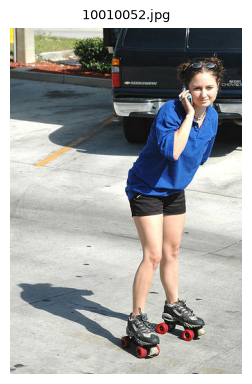

Caption:      A woman in a blue shirt and blue jeans is standing on a skateboard .
Short:        A woman stands on a skateboard in a blue shirt and blue jeans.
Explanation:  A woman in a blue shirt and blue jeans stands on a skateboard.
Story:        A woman stands on a skateboard, her blue shirt and jeans blending into the background. She leans forward slightly, balancing precariously over the board. Her eyes scan the area, searching for something she might need before taking off. As she steps back onto the skateboard, she smiles confidently, ready to embark on whatever adventure awaits.
Grounding:    ratio 0.8 | entity coverage 1.0 | names 0 | new characters 0 | new places 0 | new details 2 | repairs 1
Flags:        none



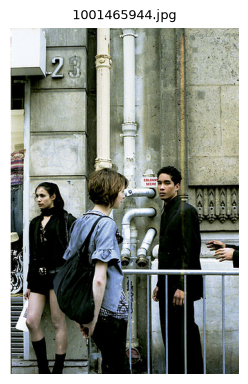

Caption:      A group of people walking down a street .
Short:        A group of people walks down a street.
Explanation:  A group of people can be seen walking down a street. The exact number of people is uncertain, but there appears to be several individuals in the scene. Each person seems to be engaged in the act of walking along the street, moving their bodies forward while maintaining balance and pace. The specific details of each individual's appearance or attire are not provided, making them indistinguishable from one another. The location is clearly set outside, likely in an urban area, as indicated by the presence of a street.
Story:        The sun was just beginning to rise over the city, casting long shadows across the cobblestone streets below. A group of people strolled leisurely along the bustling avenue, chatting animatedly under the warm morning light. Some wore casual outfits, while others sported smart suits for workdays ahead. As they walked, their footsteps echoed s

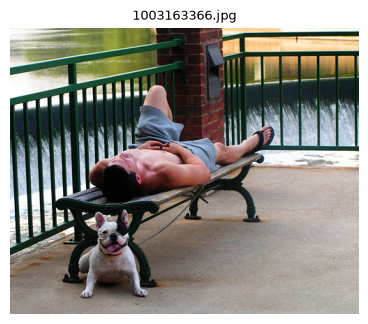

Caption:      A man and a dog are sleeping on a bench .
Short:        A man sleeps on a bench while a dog rests nearby.
Explanation:  A man and a dog are sleeping on a bench in an unspecified location. The man appears to be resting while the dog snores softly beside him. No other details about the scene are provided.
Story:        The sun was beginning to set behind the tall trees when I found myself sitting alone on a wooden bench in a quiet park. It wasn't until I saw the figure lying on the bench that my eyes widened. There was a man asleep on the bench, his face peaceful, his head resting on his arms. Next to him lay a large, fluffy dog who seemed content to snore softly beside him. The sound of birds chirping filled the air around me, adding to the serene atmosphere.
Grounding:    ratio 0.706 | entity coverage 1.0 | names 0 | new characters 1 | new places 2 | new details 2 | repairs 1
Flags:        none



In [10]:
def in_range(n, bounds):
    return bounds[0] <= n <= bounds[1]

rubric_rows = []
for record in records:
    for mode in ["short_description", "detailed_explanation", "story"]:
        report = record["grounding"][mode]
        rubric_rows.append(
            {
                "image": record["image"],
                "output": mode,
                "sentences": report["sentences"],
                "length ok": in_range(report["sentences"], STORY_STRUCTURE[mode]["sentences"]) and report["words"] <= STORY_STRUCTURE[mode]["max_words"],
                "grounded ratio": report["grounded_ratio"],
                "entity coverage": report["entity_coverage"],
                "names": report["names"],
                "new characters": report["new_characters"],
                "new places": report["new_places"],
                "new details": report["new_details"],
            }
        )
rubric_df = pd.DataFrame(rubric_rows)
rubric_summary = rubric_df.groupby("output").agg({"length ok": "mean", "grounded ratio": "mean", "entity coverage": "mean", "names": "sum", "new characters": "sum", "new places": "sum", "new details": "sum"}).round(3)
display(rubric_summary)

for record in records[:3]:
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.imshow(Image.open(record["image_path"]).convert("RGB"))
    ax.set_title(record["image"], fontsize=9)
    ax.axis("off")
    plt.show()
    print(f"Caption:      {record['caption']}")
    print(f"Short:        {record['short_description']}")
    print(f"Explanation:  {record['detailed_explanation']}")
    print(f"Story:        {record['story']}")
    report = record["grounding"]["story"]
    print(f"Grounding:    ratio {report['grounded_ratio']} | entity coverage {report['entity_coverage']} | names {report['names']} | new characters {report['new_characters']} | new places {report['new_places']} | new details {report['new_details']} | repairs {report['repairs']}")
    print(f"Flags:        {record['flags'] or 'none'}")
    print()


## 11. Compare Caption vs Story

caption → what the vision model saw (one sentence, fully grounded by construction)
story → what the language model made of it

Per record: words, sentences, distinct-word ratio, lexical overlap (Jaccard of content lemmas), novelty (share of story lemmas absent from the caption), entity and action coverage. Averages across records and one chart.


,words,sentences,distinct ratio,overlap with caption,novel lemmas,grounded ratio,entity coverage,action coverage
output,,,,,,,,
caption,11.833,1.00,0.850,1.000,0.000,1.000,1.000,1.000
short_description,11.208,1.00,0.865,0.911,0.065,0.972,1.000,0.957
detailed_explanation,31.375,2.25,0.822,0.499,0.498,0.781,0.964,0.870
story,87.125,5.50,0.779,0.129,0.868,0.561,0.900,0.587


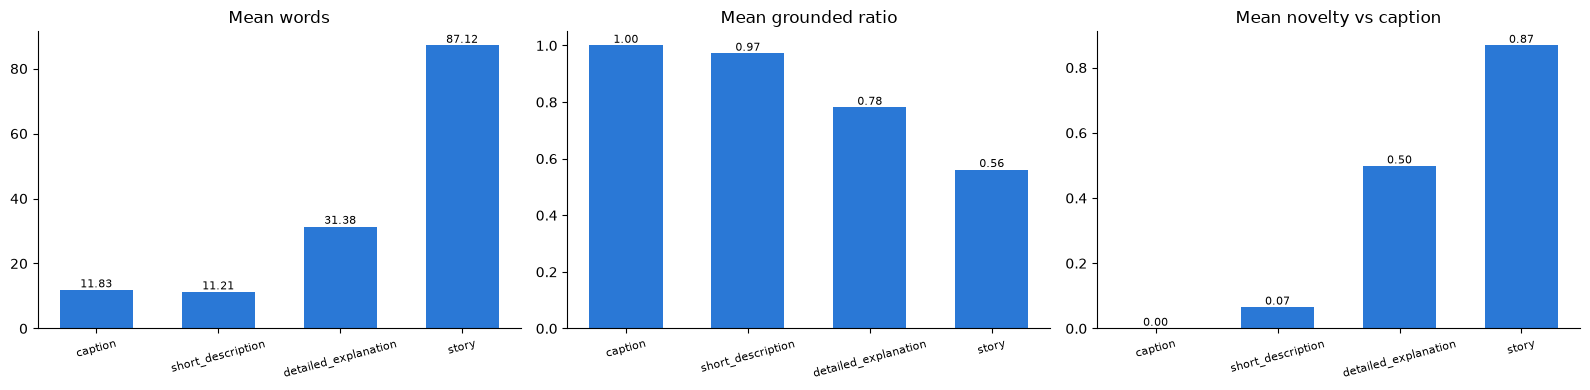

In [11]:
def content_lemmas(text):
    return {t.lemma_.lower() for t in nlp(text) if t.pos_ in ("NOUN", "PROPN", "VERB", "ADJ") and not t.is_stop}

compare_rows = []
for record in records:
    caption_set = content_lemmas(record["caption"])
    for mode in ["caption", "short_description", "detailed_explanation", "story"]:
        text = record[mode]
        report = record["grounding"][mode]
        text_set = content_lemmas(text)
        words = report["words"]
        compare_rows.append(
            {
                "output": mode,
                "words": words,
                "sentences": report["sentences"],
                "distinct ratio": len(set(lemmas(text))) / max(words, 1),
                "overlap with caption": len(text_set & caption_set) / max(len(text_set | caption_set), 1),
                "novel lemmas": len(text_set - caption_set) / max(len(text_set), 1),
                "grounded ratio": report["grounded_ratio"],
                "entity coverage": report["entity_coverage"] if report["entity_coverage"] is not None else np.nan,
                "action coverage": report["action_coverage"] if report["action_coverage"] is not None else np.nan,
            }
        )
compare_df = pd.DataFrame(compare_rows).groupby("output").mean().reindex(["caption", "short_description", "detailed_explanation", "story"]).round(3)
display(compare_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
outputs = list(compare_df.index)
for ax, column, title in zip(axes, ["words", "grounded ratio", "novel lemmas"], ["Mean words", "Mean grounded ratio", "Mean novelty vs caption"]):
    values = compare_df[column].tolist()
    bars = ax.bar(outputs, values, color="#2a78d6", width=0.6)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_title(title)
    ax.set_xticks(range(len(outputs)))
    ax.set_xticklabels(outputs, rotation=15, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 12. Visualization

Per image (first VIS_NUM_IMAGES): photograph + caption, short description, explanation and story side by side.

Across the set: grounded-ratio distributions per output type and story hallucination categories before and after the repair pass.


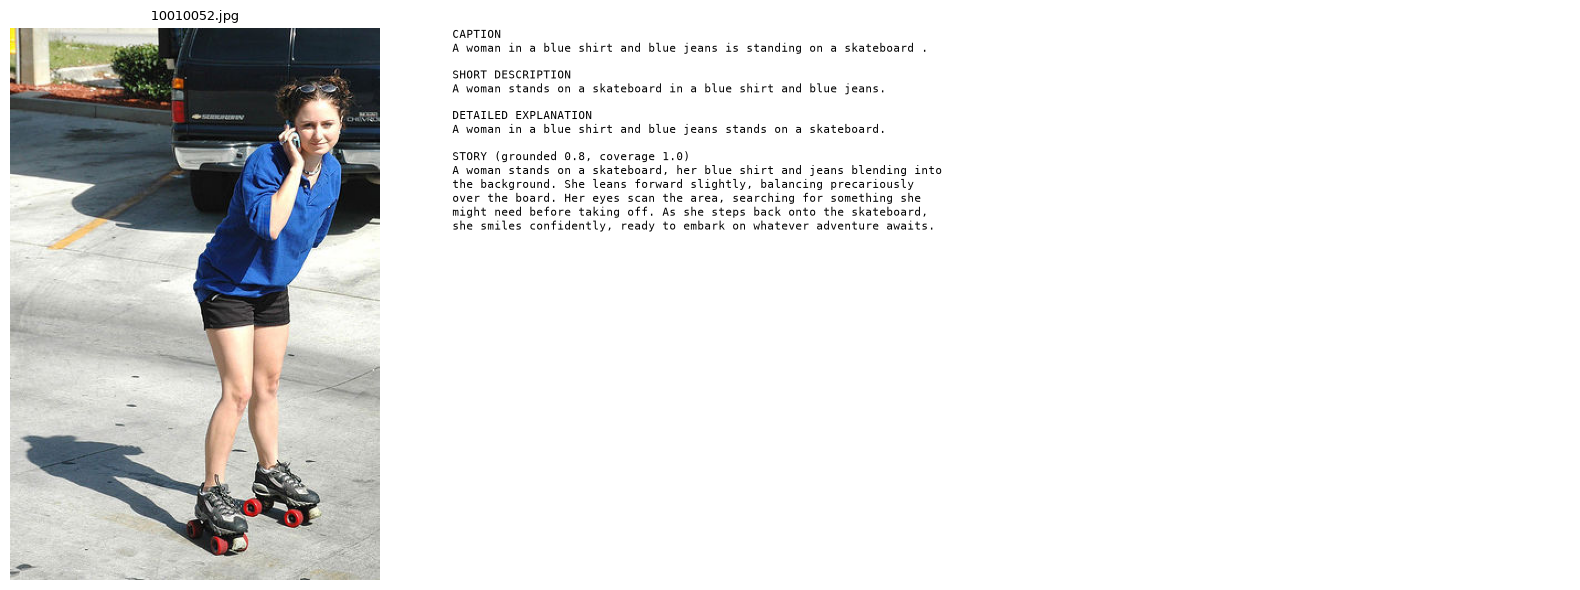

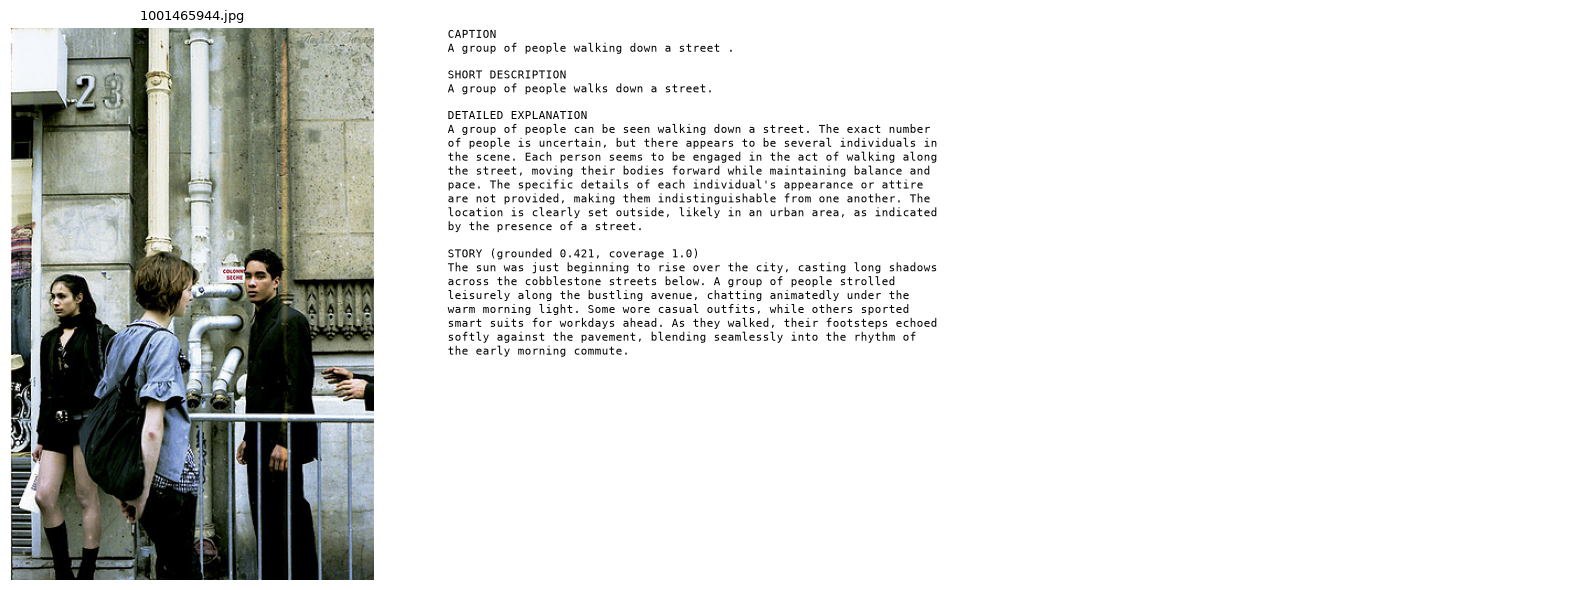

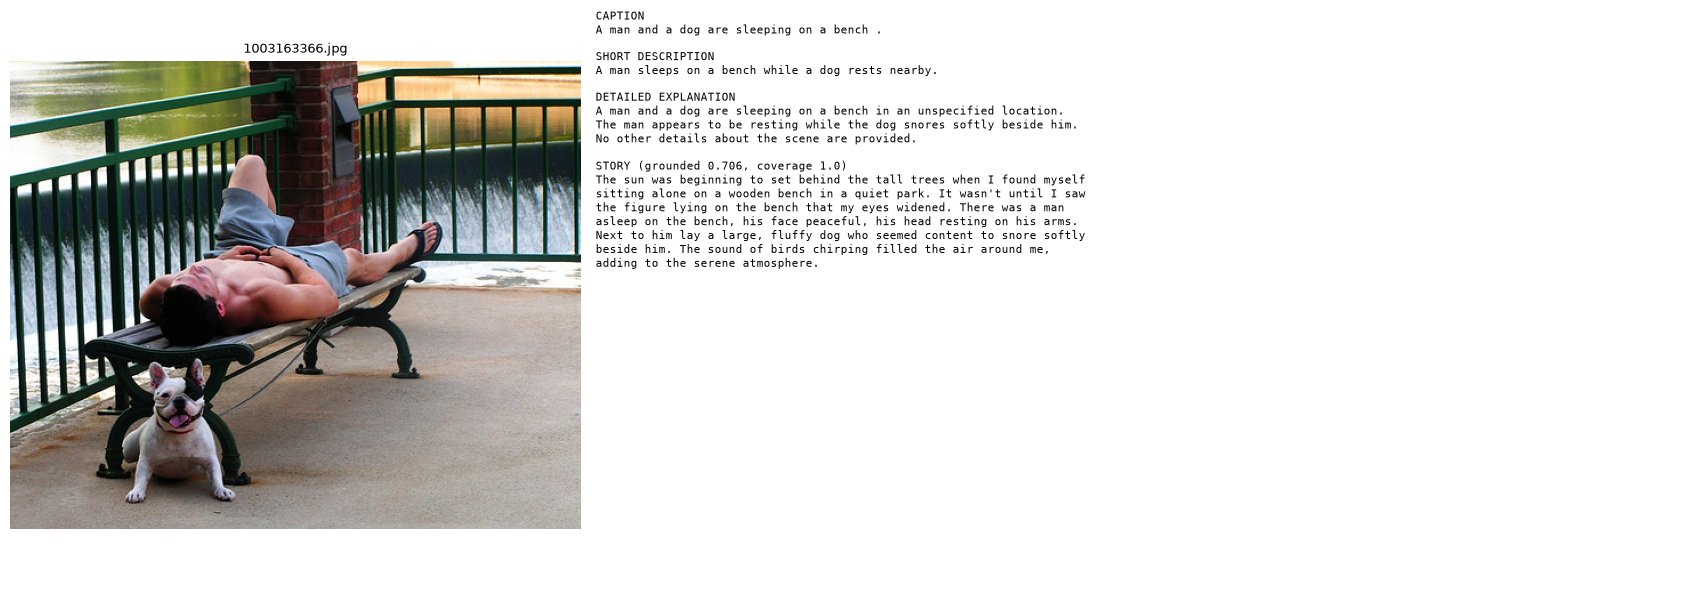

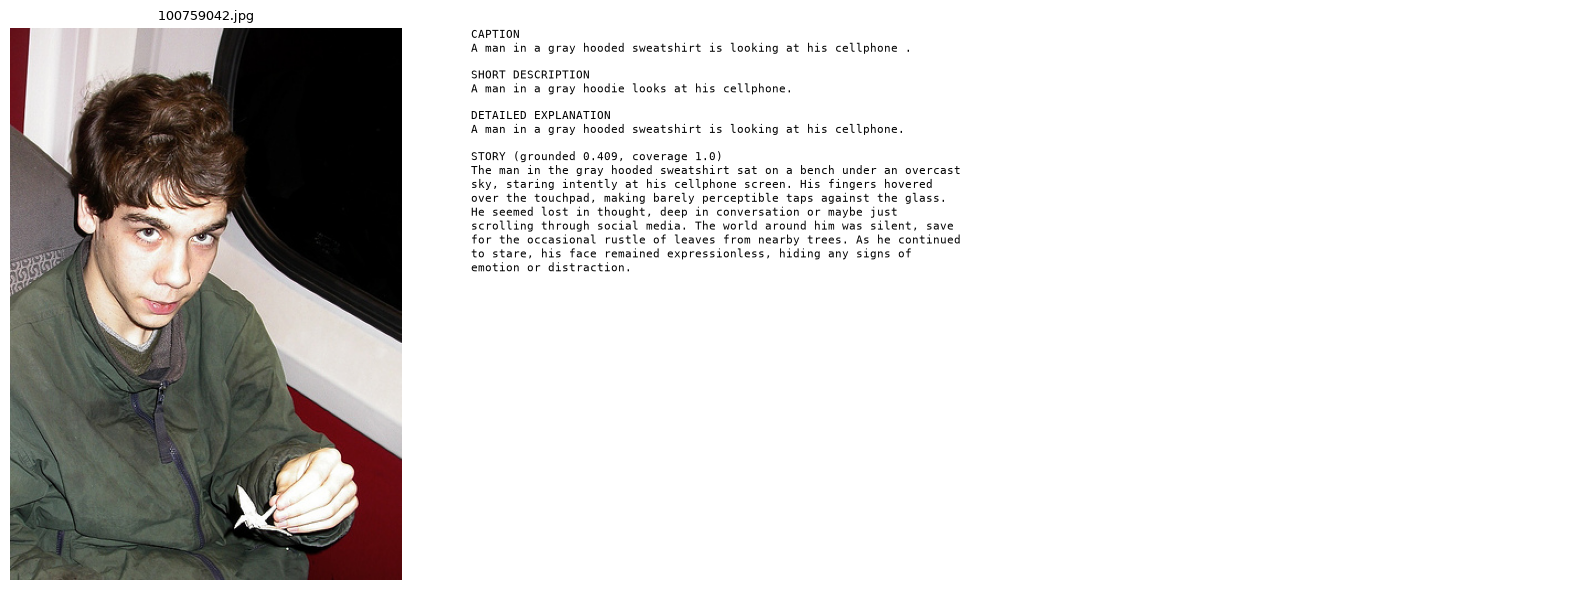

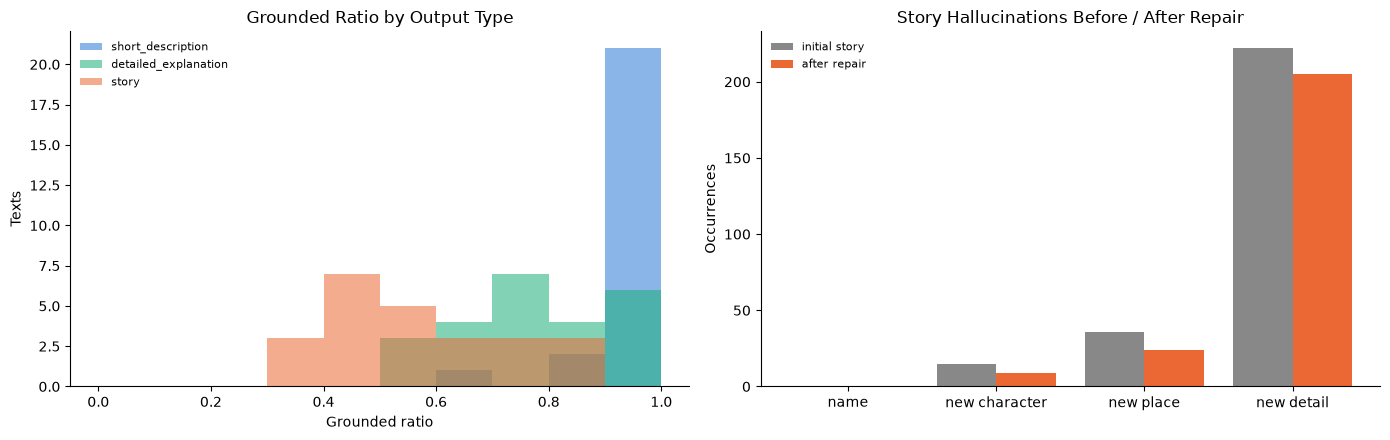

In [12]:
import textwrap

def wrap(text, width=70):
    return "\n".join(textwrap.wrap(text, width=width))

for record in records[:VIS_NUM_IMAGES]:
    fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1, 1.9]})
    axes[0].imshow(Image.open(record["image_path"]).convert("RGB"))
    axes[0].set_title(record["image"], fontsize=9)
    panel = (
        f"CAPTION\n{wrap(record['caption'])}\n\n"
        f"SHORT DESCRIPTION\n{wrap(record['short_description'])}\n\n"
        f"DETAILED EXPLANATION\n{wrap(record['detailed_explanation'])}\n\n"
        f"STORY (grounded {record['grounding']['story']['grounded_ratio']}, coverage {record['grounding']['story']['entity_coverage']})\n{wrap(record['story'])}"
    )
    axes[1].text(0.0, 1.0, panel, va="top", ha="left", fontsize=8, family="monospace")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
bins = np.linspace(0, 1, 11)
for mode, color in [("short_description", "#2a78d6"), ("detailed_explanation", "#1baf7a"), ("story", "#eb6834")]:
    axes[0].hist([r["grounding"][mode]["grounded_ratio"] for r in records], bins=bins, alpha=0.55, color=color, label=mode)
axes[0].set_xlabel("Grounded ratio")
axes[0].set_ylabel("Texts")
axes[0].set_title("Grounded Ratio by Output Type")
axes[0].legend(frameon=False, fontsize=8)

before = Counter(h["category"] for r in records for h in grounding_report(r["story_initial"], r)["hallucinations"])
after = Counter(h["category"] for r in records for h in r["grounding"]["story"]["hallucinations"])
categories = ["name", "new character", "new place", "new detail"]
x = np.arange(len(categories))
axes[1].bar(x - 0.2, [before.get(c, 0) for c in categories], width=0.4, color="#888888", label="initial story")
axes[1].bar(x + 0.2, [after.get(c, 0) for c in categories], width=0.4, color="#eb6834", label="after repair")
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel("Occurrences")
axes[1].set_title("Story Hallucinations Before / After Repair")
axes[1].legend(frameon=False, fontsize=8)
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 13. Save Generated Stories

results/generated_stories.jsonl → per image: caption, prompt, short description, explanation, initial and final story, grounding reports
results/story_generation_summary.csv → one row per image with the key metrics
docs/story_examples.md → the first five examples, readable


In [13]:
RESULTS_DIR.mkdir(exist_ok=True)
DOCS_DIR.mkdir(exist_ok=True)

stories_path = RESULTS_DIR / "generated_stories.jsonl"
summary_path = RESULTS_DIR / "story_generation_summary.csv"
examples_path = DOCS_DIR / "story_examples.md"

export_keys = ["image", "source", "caption", "flags", "prompt", "short_description", "detailed_explanation", "story_initial", "story", "grounding"]
with open(stories_path, "w", encoding="utf-8") as f:
    for record in records:
        f.write(json.dumps({key: record[key] for key in export_keys} | {"story_model": STORY_MODEL_NAME if llm_available else "fallback"}) + "\n")

summary_out = pd.DataFrame(
    {
        "image": [r["image"] for r in records],
        "caption": [r["caption"] for r in records],
        "short_description": [r["short_description"] for r in records],
        "story": [r["story"] for r in records],
        "story_grounded_ratio": [r["grounding"]["story"]["grounded_ratio"] for r in records],
        "story_entity_coverage": [r["grounding"]["story"]["entity_coverage"] for r in records],
        "story_names": [r["grounding"]["story"]["names"] for r in records],
        "story_new_characters": [r["grounding"]["story"]["new_characters"] for r in records],
        "story_new_places": [r["grounding"]["story"]["new_places"] for r in records],
        "story_repairs": [r["grounding"]["story"]["repairs"] for r in records],
        "flags": [len(r["flags"]) for r in records],
    }
)
summary_out.to_csv(summary_path, index=False)

lines = ["# Story Generation Examples - VisionNarrator", "", f"Story model: `{STORY_MODEL_NAME if llm_available else 'fallback (no LLM)'}` | records: {len(records)}", ""]
for record in records[:5]:
    report = record["grounding"]["story"]
    lines += [
        f"## {record['image']}",
        "",
        f"- **Caption:** {record['caption']}",
        f"- **Short description:** {record['short_description']}",
        f"- **Detailed explanation:** {record['detailed_explanation']}",
        f"- **Story:** {record['story']}",
        f"- **Grounding:** ratio {report['grounded_ratio']}, entity coverage {report['entity_coverage']}, names {report['names']}, new characters {report['new_characters']}, new places {report['new_places']}, new details {report['new_details']}",
        "",
    ]
examples_path.write_text("\n".join(lines), encoding="utf-8")

print(f"Saved: {stories_path} ({len(records)} records)")
print(f"Saved: {summary_path}")
print(f"Saved: {examples_path}")


Saved: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\results\generated_stories.jsonl (24 records)
Saved: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\results\story_generation_summary.csv
Saved: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\docs\story_examples.md


## 14. Final End-to-End Demonstration

image
      ↓ captioner (ViT → projection → GPT-2, src/models/vit_gpt2_captioner.pt)
caption (beam) + caption (greedy)
      ↓ src/semantics.py (Notebook 08 logic)
structured record + consistency flags + prompt block
      ↓ story model (sections 4–9)
short description → detailed explanation → story → grounding check

Runs on images that Notebook 08 never processed: src/data/demo/* if present, otherwise the next unseen test images. `narrate(image_path)` is the whole VisionNarrator pipeline in one call.


c:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\venv\Lib\site-packages\transformers\generation\utils.py:1185: UserWarning: Passing `no_repeat_ngram_size` with `inputs_embeds` and without `input_ids` to `generate` will apply n-gram constraints only to newly generated tokens, not to the prompt.
  warnings.warn(


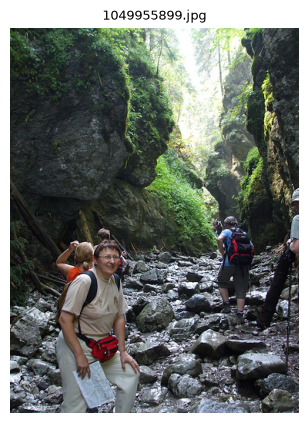

Caption (beam):   A man and a woman are walking along a rocky path .
Caption (greedy): A man and a woman are hiking along a rocky path .
Flags:            none
Setting: outdoor, along the path
Characters: a man; a woman
Objects: none identified
Actions: man walk along path
Relations: man walk along path
Caption: A man and a woman are walking along a rocky path .

Short:            A man and a woman are walking along a rocky path.
Explanation:      A man and a woman are walking along a rocky path together. The exact appearance of both individuals is uncertain but they appear to be engaged in an activity related to their surroundings.
Story:            A man and a woman walked together along an old, winding path beside a babbling stream. The sun shone brightly overhead, casting dappled shadows through the trees on either side of the path. The air was fresh and fragrant, filled with the sweet scent of blooming wildflowers. They talked quietly, sharing stories and laughter. Occasionally, o

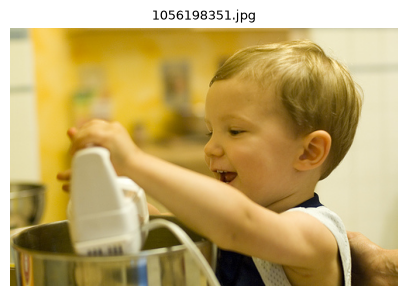

Caption (beam):   A young boy in a blue shirt is stirring a bowl .
Caption (greedy): A young boy is stirring a bowl of food .
Flags:            none
Setting: unspecified
Characters: a young boy wearing blue shirt
Objects: a bowl
Actions: boy stir bowl
Relations: boy stir bowl
Caption: A young boy in a blue shirt is stirring a bowl .

Short:            A young boy in a blue shirt is stirring a bowl.
Explanation:      A young boy in a blue shirt is stirring a bowl.
Story:            The young boy in a blue shirt sat at a table, holding a wooden spoon and looking into a large, dark green bowl filled with brown rice. He stirred the contents gently, his eyes focused intently on the simmering mixture bubbling away beneath the surface. As he worked, beads of sweat formed on his forehead, but his determination remained unwavering. The aroma of cooking rice wafted through the room, mingling with the scent of fresh laundry hanging on the line outside. Eventually, the boy paused, satisfied with t

In [14]:
from transformers import ViTModel, ViTConfig, GPT2LMHeadModel, GPT2Config, GPT2TokenizerFast

captioner_ckpt = torch.load(MODEL_DIR / "vit_gpt2_captioner.pt", map_location="cpu")
cap_config = captioner_ckpt["config"]

class VisualProjection(nn.Module):
    def __init__(self, vit_dim=768, gpt2_dim=768, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(vit_dim, gpt2_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(gpt2_dim, gpt2_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.fc2(self.act(self.fc1(x))))

class VisionNarrator(nn.Module):
    def __init__(self, vit, projection, gpt2):
        super().__init__()
        self.vit = vit
        self.projection = projection
        self.gpt2 = gpt2

    def encode_images(self, images):
        return self.projection(self.vit(pixel_values=images).last_hidden_state)

captioner = VisionNarrator(
    ViTModel(ViTConfig.from_pretrained(cap_config["vit_model_name"]), add_pooling_layer=False),
    VisualProjection(dropout=cap_config["dropout"]),
    GPT2LMHeadModel(GPT2Config.from_pretrained(cap_config["gpt2_model_name"])),
)
captioner.load_state_dict(captioner_ckpt["model_state"], strict=True)
captioner = captioner.to(device).eval()
cap_tokenizer = GPT2TokenizerFast.from_pretrained(cap_config["gpt2_model_name"])
cap_tokenizer.pad_token = cap_tokenizer.eos_token

cap_transform = T.Compose([T.Resize((cap_config["img_size"], cap_config["img_size"])), T.ToTensor(), T.Normalize(mean=cap_config["image_mean"], std=cap_config["image_std"])])

@torch.no_grad()
def caption_image(image_path, num_beams):
    pixels = cap_transform(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)
    prefix = captioner.encode_images(pixels)
    kwargs = dict(inputs_embeds=prefix, attention_mask=torch.ones(prefix.shape[:2], dtype=torch.long, device=device), max_new_tokens=cap_config["max_new_tokens"], do_sample=False, num_beams=num_beams, no_repeat_ngram_size=cap_config["no_repeat_ngram"], eos_token_id=cap_tokenizer.eos_token_id, pad_token_id=cap_tokenizer.eos_token_id)
    if num_beams > 1:
        kwargs["early_stopping"] = True
    return cap_tokenizer.decode(captioner.gpt2.generate(**kwargs)[0], skip_special_tokens=True).strip()

def narrate(image_path, seed=SEED):
    image_path = Path(image_path)
    caption = caption_image(image_path, cap_config["num_beams"])
    greedy_caption = caption_image(image_path, 1)
    rep = sem.build_representation(image_path.name, "demo", caption)
    greedy_rep = sem.build_representation(image_path.name, "demo", greedy_caption)
    rep["flags"], jaccard = sem.check_consistency(rep, greedy_rep)
    for e in rep["entities"]:
        e["confidence"] = None
    for a in rep["actions"]:
        a["confidence"] = None
    record = {
        "image": image_path.name,
        "source": "demo",
        "image_path": str(image_path),
        "caption": caption,
        "greedy_caption": greedy_caption,
        "semantics": {"entities": rep["entities"], "actions": rep["actions"], "attributes": rep["attributes"], "scene": rep["scene"], "relationships": rep["relationships"]},
        "flags": rep["flags"],
        "prompt": sem.story_prompt(rep),
    }
    record["short_description"] = generate_for(record, "short_description", seed=seed)
    record["detailed_explanation"], explanation_report, _ = check_and_repair(record, "detailed_explanation", generate_for(record, "detailed_explanation", seed=seed), seed=seed)
    record["story"], story_report, _ = check_and_repair(record, "story", generate_for(record, "story", seed=seed), seed=seed)
    record["grounding"] = {"detailed_explanation": explanation_report, "story": story_report}
    return record

seen = {r["image"] for r in records}
demo_candidates = sorted(p for p in DEMO_DIR.glob("*") if p.suffix.lower() in (".jpg", ".jpeg", ".png")) if DEMO_DIR.exists() else []
if not demo_candidates:
    demo_candidates = [Path(p) for img, p in test_paths.items() if img not in seen]
demo_paths = demo_candidates[:DEMO_NUM_IMAGES]

for path in demo_paths:
    start = time.time()
    result = narrate(path)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(Image.open(path).convert("RGB"))
    ax.set_title(path.name, fontsize=9)
    ax.axis("off")
    plt.show()
    print(f"Caption (beam):   {result['caption']}")
    print(f"Caption (greedy): {result['greedy_caption']}")
    print(f"Flags:            {result['flags'] or 'none'}")
    print(result["prompt"])
    print()
    print(f"Short:            {result['short_description']}")
    print(f"Explanation:      {result['detailed_explanation']}")
    print(f"Story:            {result['story']}")
    report = result["grounding"]["story"]
    print(f"Grounding:        ratio {report['grounded_ratio']} | entity coverage {report['entity_coverage']} | names {report['names']} | new characters {report['new_characters']} | new places {report['new_places']} | new details {report['new_details']} | repairs {report['repairs']}")
    print(f"({time.time() - start:.1f}s end to end)")
    print("=" * 100)
